# My End-to-End ML Pipeline on Tesla Sales Data (Week 2 Assignment)

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV,RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
df=pd.read_csv("/content/drive/MyDrive/tesla_deliveries_dataset_2015_2025.csv")
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
df.dtypes

,0
Year,int64
Month,int64
Region,object
Model,object
Estimated_Deliveries,int64
Production_Units,int64
Avg_Price_USD,float64
Battery_Capacity_kWh,int64
Range_km,int64
CO2_Saved_tons,float64


In [4]:
df.isna().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [7]:
df.shape

(2640, 12)

In [8]:
df["Region"].value_counts()

,count
Region,
Europe,660
Asia,660
North America,660
Middle East,660


In [9]:
df["Model"].value_counts()

,count
Model,
Model S,528
Model X,528
Model 3,528
Model Y,528
Cybertruck,528


In [10]:
df["Source_Type"].value_counts()

,count
Source_Type,
Interpolated (Month),884
Official (Quarter),884
Estimated (Region),872


#Exploratory Data Analysis (EDA)

#Distribution of Avg Price USD

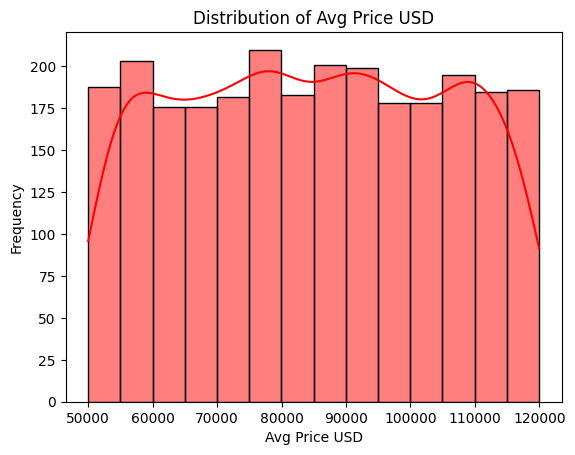

In [11]:
sns.histplot(df['Avg_Price_USD'],kde=True,color='red')
plt.xlabel('Avg Price USD')
plt.ylabel('Frequency')
plt.title('Distribution of Avg Price USD')
plt.show()

#Numeric Column Distribution

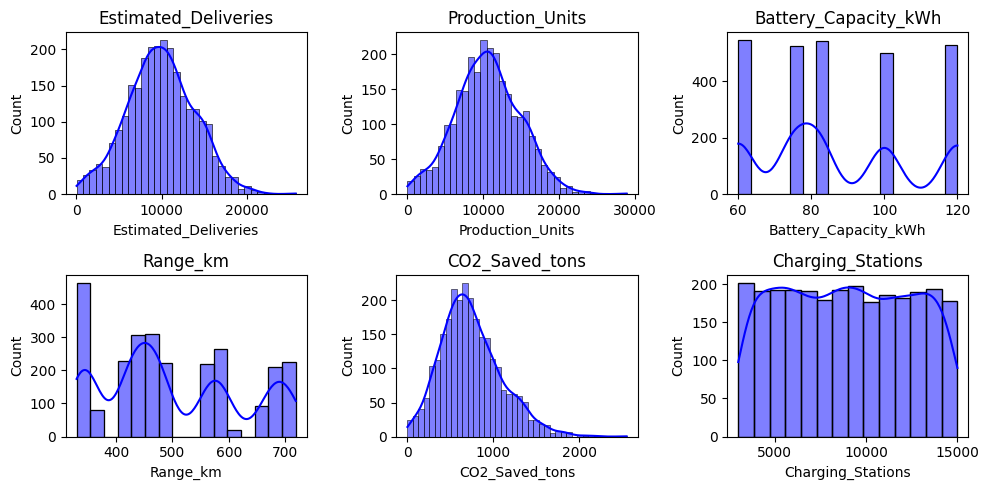

In [12]:
cols_hist = ['Estimated_Deliveries','Production_Units','Battery_Capacity_kWh','Range_km','CO2_Saved_tons','Charging_Stations']
plt.figure(figsize=(10,5))
for col in cols_hist:
    plt.subplot(2,3,cols_hist.index(col)+1)
    sns.histplot(df[col],kde=True,color='blue')
    plt.title(col)
plt.tight_layout()
plt.show()

#Categorical Column Distribution

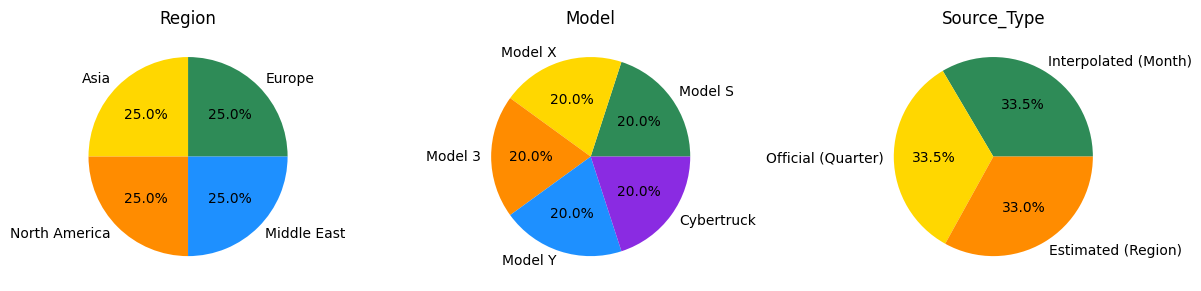

In [13]:
cols_pie = ['Region','Model','Source_Type']
plt.figure(figsize=(12,5))
for col in cols_pie:
    plt.subplot(1,3,cols_pie.index(col)+1)
    plt.pie(df[col].value_counts(),labels=df[col].value_counts().index,autopct='%1.1f%%', colors = ['#2E8B57','#FFD700','#FF8C00','#1E90FF','#8A2BE2']
)
    plt.title(col)
plt.tight_layout()
plt.show()

#Average price USD by Region

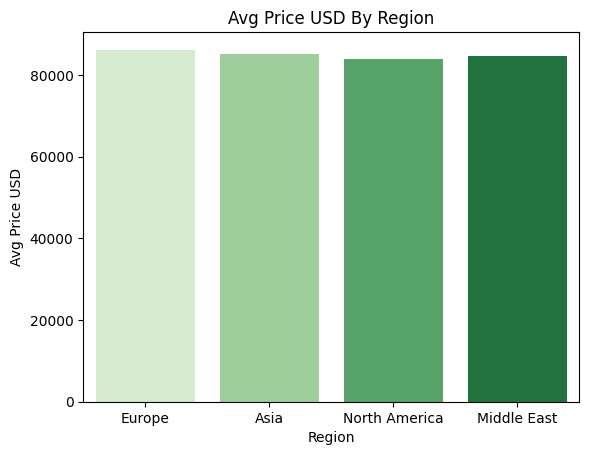

In [14]:
sns.barplot(x='Region',y='Avg_Price_USD',data=df , ci=False,palette='Greens')
plt.xlabel('Region')
plt.ylabel('Avg Price USD')
plt.title('Avg Price USD By Region')
plt.show()

#Avg Price USD By Model

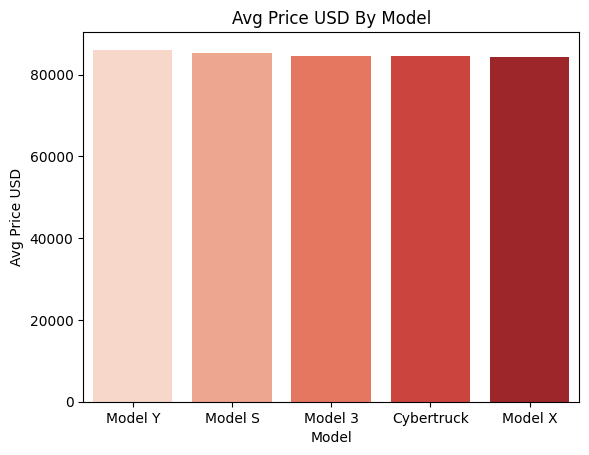

In [15]:
models = df.groupby('Model')['Avg_Price_USD'].mean().sort_values(ascending=False)
sns.barplot(x=models.index,y=models.values,palette='Reds')
plt.xlabel('Model')
plt.ylabel('Avg Price USD')
plt.title('Avg Price USD By Model')
plt.show()

#Impact of Avg Price (USD) on columns

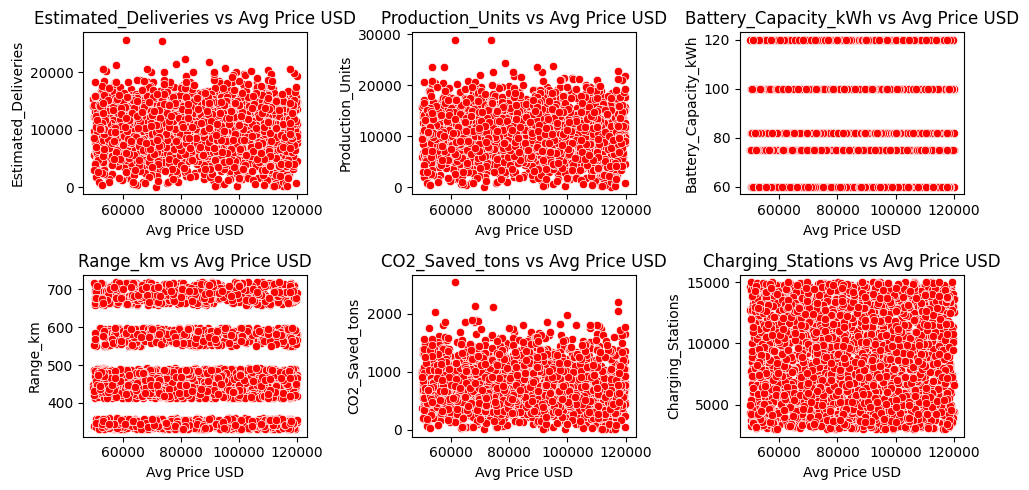

In [16]:
cols_scatter = ['Estimated_Deliveries','Production_Units','Battery_Capacity_kWh','Range_km','CO2_Saved_tons','Charging_Stations']
plt.figure(figsize=(10,5))
for col in cols_scatter:
    plt.subplot(2,3,cols_scatter.index(col)+1)
    sns.scatterplot(x=df['Avg_Price_USD'],y=df[col],color='red')
    plt.xlabel('Avg Price USD')
    plt.ylabel(col)
    plt.title(f'{col} vs Avg Price USD')
plt.tight_layout()
plt.show()

#Avg Price USD By Month

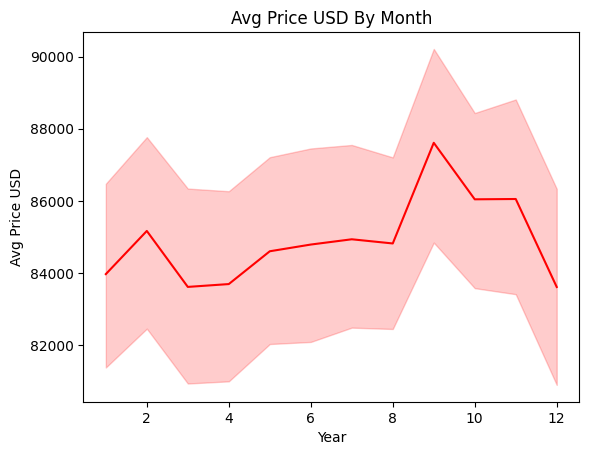

In [17]:
sns.lineplot(x='Month',y='Avg_Price_USD',data=df,color='red')
plt.xlabel('Year')
plt.ylabel('Avg Price USD')
plt.title('Avg Price USD By Month')
plt.show()

#Avg Price USD By Year

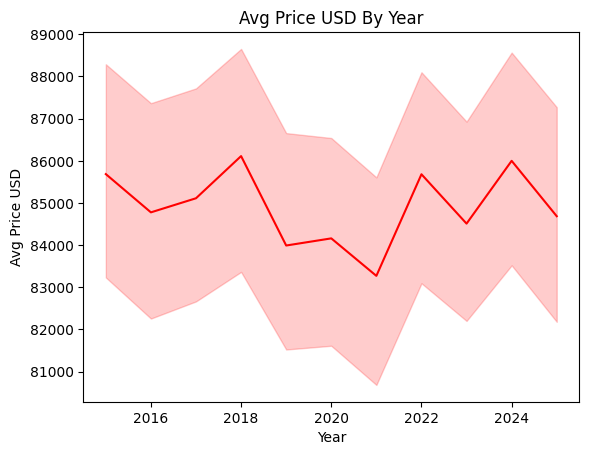

In [18]:
sns.lineplot(x='Year',y='Avg_Price_USD',data=df,color='red')
plt.xlabel('Year')
plt.ylabel('Avg Price USD')
plt.title('Avg Price USD By Year')
plt.show()

#Checking and Fixing Anomalies using IQR
Okay, so I noticed some anomalies in columns like `Production_Units` and `CO2_Saved_tons`. Instead of dropping rows and breaking our time sequence, I am using the IQR method (Interquartile Range) to find the upper and lower bounds and clipping the extreme values so they don't mess up our model training.

In [19]:
df_cleaned = df.sort_values(by=['Year', 'Month']).reset_index(drop=True)
skewed_cols = ['Production_Units', 'Estimated_Deliveries', 'CO2_Saved_tons']

print("─" * 60)
print("  Outlier Clipping Report")
print("─" * 60)

for col in skewed_cols:
    Q1  = df_cleaned[col].quantile(0.25)
    Q3  = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR
    n_out = ((df_cleaned[col] < lo) | (df_cleaned[col] > hi)).sum()
    df_cleaned[col] = np.clip(df_cleaned[col], lo, hi)
    print(f"  {col:<25}  clipped {n_out:>3} rows  →  [{lo:.1f}, {hi:.1f}]")

print("─" * 60)
print(f"df_cleaned ready  |  shape: {df_cleaned.shape}")


────────────────────────────────────────────────────────────
  Outlier Clipping Report
────────────────────────────────────────────────────────────
  Production_Units           clipped  12 rows  →  [-632.9, 21930.1]
  Estimated_Deliveries       clipped  12 rows  →  [-535.4, 20337.6]
  CO2_Saved_tons             clipped  45 rows  →  [-166.6, 1610.0]
────────────────────────────────────────────────────────────
df_cleaned ready  |  shape: (2640, 12)


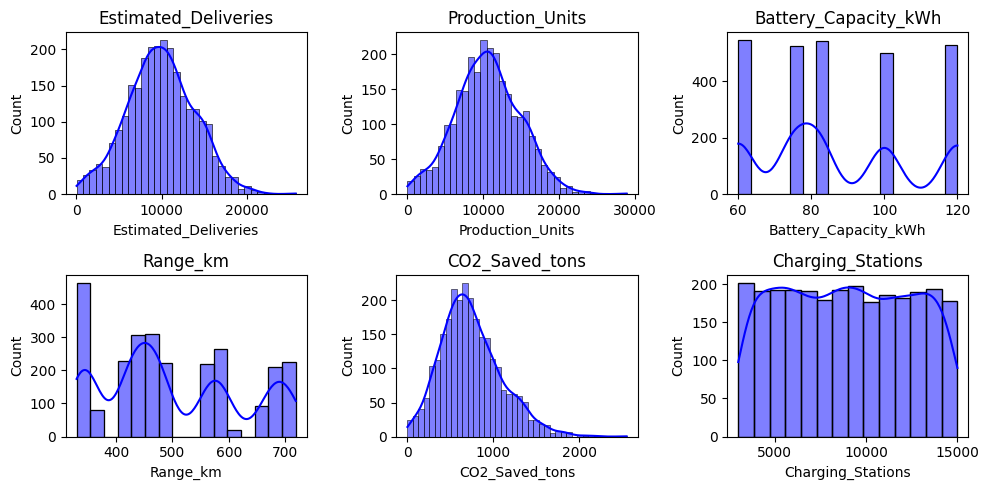

In [20]:
cols_hist = ['Estimated_Deliveries','Production_Units','Battery_Capacity_kWh','Range_km','CO2_Saved_tons','Charging_Stations']
plt.figure(figsize=(10,5))
for col in cols_hist:
    plt.subplot(2,3,cols_hist.index(col)+1)
    sns.histplot(df[col],kde=True,color='blue')
    plt.title(col)
plt.tight_layout()
plt.show()

###Feature Engineering (Cyclical Months)
Months go in a cycle (1 to 12), so regular models can get confused thinking month 12 is totally far from month 1. To fix this, I am converting the months into Sine and Cosine features so the model understands the repeating seasonal nature of sales data. I am also calculating a domain ratio metric.

In [21]:
df_feat = df_cleaned.copy()

df_feat['Month_Sin'] = np.sin(2 * np.pi * df_feat['Month'] / 12)
df_feat['Month_Cos'] = np.cos(2 * np.pi * df_feat['Month'] / 12)

In [22]:
for lag in [1, 3, 6]:
    df_feat[f'Delivery_Lag{lag}'] = df_feat['Estimated_Deliveries'].shift(lag)
    df_feat[f'Production_Lag{lag}'] = df_feat['Production_Units'].shift(lag)

for window in [3, 6]:
    df_feat[f'Delivery_Roll{window}_Mean'] = df_feat['Estimated_Deliveries'].rolling(window).mean()
    df_feat[f'Delivery_Roll{window}_Std']  = df_feat['Estimated_Deliveries'].rolling(window).std()

df_feat['Battery_x_Range'] = df_feat['Battery_Capacity_kWh'] * df_feat['Range_km']
df_feat['Price_x_Charging'] = df_feat['Avg_Price_USD'] * df_feat['Charging_Stations']

df_feat['Delivery_Rate'] = df_feat['Estimated_Deliveries'] / (df_feat['Production_Units'] + 1)
df_feat.dropna(inplace=True)
df_feat.reset_index(drop=True, inplace=True)

print(f"Feature engineering complete")
print(f"Total features : {df_feat.shape[1]}")
print(f"Dataset rows   : {df_feat.shape[0]}")
print(f"\nNew features added:")
new_feats = [c for c in df_feat.columns if c not in df.columns]
for f in new_feats: print(f"   + {f}")

Feature engineering complete
Total features : 27
Dataset rows   : 2634

New features added:
   + Month_Sin
   + Month_Cos
   + Delivery_Lag1
   + Production_Lag1
   + Delivery_Lag3
   + Production_Lag3
   + Delivery_Lag6
   + Production_Lag6
   + Delivery_Roll3_Mean
   + Delivery_Roll3_Std
   + Delivery_Roll6_Mean
   + Delivery_Roll6_Std
   + Battery_x_Range
   + Price_x_Charging
   + Delivery_Rate


#Split Data Safely (No Future Data Leakage!)
This is super important! Because this is time-series data, I cannot use standard random train-test splits or random K-Fold. If I shuffle randomly, future data will leak into the past, giving a fake high score.

So, I am keeping the last 15% completely separate for final testing, and I am using `TimeSeriesSplit(n_splits=5)` to test our models using an expanding timeline window.

In [23]:
target_col   = 'Estimated_Deliveries'
num_features = ['Year', 'Month_Sin', 'Month_Cos', 'Production_Units',
                'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
                'CO2_Saved_tons', 'Charging_Stations',
                'Delivery_Lag1', 'Delivery_Lag3', 'Delivery_Lag6',
                'Production_Lag1', 'Delivery_Roll3_Mean', 'Delivery_Roll6_Mean',
                'Delivery_Roll3_Std', 'Battery_x_Range',
                'Price_x_Charging', 'Delivery_Rate']
cat_features = ['Region', 'Model']

In [24]:
X = df_feat[num_features + cat_features]
y = df_feat[target_col]
split_idx            = int(len(X) * 0.85)
X_train, X_test      = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test      = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train size : {len(X_train)} rows  ({split_idx} / {len(X)})")
print(f"Test  size : {len(X_test)} rows")

Train size : 2238 rows  (2238 / 2634)
Test  size : 396 rows


#Setting up Transformers and Pipeline Framework
Here, I am defining which columns are numbers and which are text (categories). I use `StandardScaler` to normalize the numbers and `OneHotEncoder` for text columns, and then wrap everything inside a clean `Pipeline` to keep things organized.

In [25]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(),                  num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

In [26]:
def build_and_eval(name, regressor, X_tr, y_tr, X_te, y_te, cv=None):
    pipe = Pipeline([('preprocessor', preprocessor),
                     ('regressor',    regressor)])
    pipe.fit(X_tr, y_tr)
    pred  = pipe.predict(X_te)
    rmse  = np.sqrt(mean_squared_error(y_te, pred))
    mae   = mean_absolute_error(y_te, pred)
    r2    = r2_score(y_te, pred)
    cv_r2 = cross_val_score(pipe, X_tr, y_tr, cv=cv or 5, scoring='r2').mean()
    return {"name": name, "pipe": pipe, "pred": pred,
            "rmse": rmse, "mae": mae, "r2": r2, "cv_r2": cv_r2}

In [27]:
tscv = TimeSeriesSplit(n_splits=5)

In [28]:
models_results = []
models_results.append(build_and_eval("Linear Regression",
    LinearRegression(), X_train, y_train, X_test, y_test, tscv))
models_results.append(build_and_eval("Ridge (α=10)",
    Ridge(alpha=10), X_train, y_train, X_test, y_test, tscv))
models_results.append(build_and_eval("Lasso (α=10)",
    Lasso(alpha=10, max_iter=5000), X_train, y_train, X_test, y_test, tscv))
models_results.append(build_and_eval("Random Forest",
    RandomForestRegressor(n_estimators=200, random_state=42), X_train, y_train, X_test, y_test, tscv))
models_results.append(build_and_eval("Gradient Boosting",
    GradientBoostingRegressor(n_estimators=200, random_state=42), X_train, y_train, X_test, y_test, tscv))
models_results.append(build_and_eval("XGBoost",
    xgb.XGBRegressor(n_estimators=200, verbosity=0, random_state=42), X_train, y_train, X_test, y_test, tscv))

print(f"{'Model':<25} {'RMSE':>10} {'MAE':>10} {'R²':>8} {'CV-R²':>8}")
print("─" * 65)
for r in models_results:
    print(f"{r['name']:<25} {r['rmse']:>10,.1f} {r['mae']:>10,.1f} {r['r2']:>8.4f} {r['cv_r2']:>8.4f}")

Model                           RMSE        MAE       R²    CV-R²
─────────────────────────────────────────────────────────────────
Linear Regression              150.9      106.1   0.9983   0.9985
Ridge (α=10)                   156.0      108.6   0.9982   0.9971
Lasso (α=10)                   154.4      107.4   0.9982   0.9985
Random Forest                   88.5       59.2   0.9994   0.9979
Gradient Boosting               73.6       56.8   0.9996   0.9992
XGBoost                         93.6       70.4   0.9993   0.9983


#Hyperparameter Tuning

In [29]:
print("Tuning XGBoost (RandomizedSearchCV)")
xgb_pipe = Pipeline([('preprocessor', preprocessor),
                     ('regressor', xgb.XGBRegressor(verbosity=0, random_state=42))])

xgb_param_dist = {
    'regressor__n_estimators':     [100, 200, 300, 500],
    'regressor__max_depth':        [3, 4, 5, 6],
    'regressor__learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'regressor__subsample':        [0.6, 0.8, 1.0],
    'regressor__colsample_bytree': [0.6, 0.8, 1.0],
    'regressor__reg_alpha':        [0, 0.1, 0.5],
    'regressor__reg_lambda':       [0.5, 1.0, 2.0],
}

Tuning XGBoost (RandomizedSearchCV)


In [30]:
xgb_rs = RandomizedSearchCV(xgb_pipe, xgb_param_dist, n_iter=30,
                             cv=tscv, scoring='r2', random_state=42, n_jobs=-1)
xgb_rs.fit(X_train, y_train)
best_xgb_pred = xgb_rs.best_estimator_.predict(X_test)

print(f"  Best params : {xgb_rs.best_params_}")
print(f"  CV R²       : {xgb_rs.best_score_:.4f}")
print(f"  Test R²     : {r2_score(y_test, best_xgb_pred):.4f}")
print(f"  Test RMSE   : {np.sqrt(mean_squared_error(y_test, best_xgb_pred)):,.1f}")
models_results.append({
    "name": "XGBoost (Tuned)", "pipe": xgb_rs.best_estimator_,
    "pred": best_xgb_pred,
    "rmse": np.sqrt(mean_squared_error(y_test, best_xgb_pred)),
    "mae":  mean_absolute_error(y_test, best_xgb_pred),
    "r2":   r2_score(y_test, best_xgb_pred),
    "cv_r2": xgb_rs.best_score_
})

  Best params : {'regressor__subsample': 0.8, 'regressor__reg_lambda': 2.0, 'regressor__reg_alpha': 0.5, 'regressor__n_estimators': 500, 'regressor__max_depth': 3, 'regressor__learning_rate': 0.1, 'regressor__colsample_bytree': 1.0}
  CV R²       : 0.9990
  Test R²     : 0.9996
  Test RMSE   : 73.4


In [31]:
print("Tuning Random Forest (GridSearchCV)")

rf_pipe = Pipeline([('preprocessor', preprocessor),
                    ('regressor', RandomForestRegressor(random_state=42))])
rf_param_grid = {
    'regressor__n_estimators':   [200, 300],
    'regressor__max_depth':      [None, 10, 20],
    'regressor__min_samples_split': [2, 5],
    'regressor__max_features':   ['sqrt', 0.7],
}

Tuning Random Forest (GridSearchCV)


In [32]:
rf_gs = GridSearchCV(rf_pipe, rf_param_grid, cv=tscv,
                     scoring='r2', n_jobs=-1)
rf_gs.fit(X_train, y_train)
best_rf_pred = rf_gs.best_estimator_.predict(X_test)

print(f"  Best params : {rf_gs.best_params_}")
print(f"  CV R²       : {rf_gs.best_score_:.4f}")
print(f"  Test R²     : {r2_score(y_test, best_rf_pred):.4f}")
print(f"  Test RMSE   : {np.sqrt(mean_squared_error(y_test, best_rf_pred)):,.1f}")
models_results.append({
    "name": "RF (Tuned)", "pipe": rf_gs.best_estimator_,
    "pred": best_rf_pred,
    "rmse": np.sqrt(mean_squared_error(y_test, best_rf_pred)),
    "mae":  mean_absolute_error(y_test, best_rf_pred),
    "r2":   r2_score(y_test, best_rf_pred),
    "cv_r2": rf_gs.best_score_
})

  Best params : {'regressor__max_depth': None, 'regressor__max_features': 0.7, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 300}
  CV R²       : 0.9966
  Test R²     : 0.9989
  Test RMSE   : 122.9


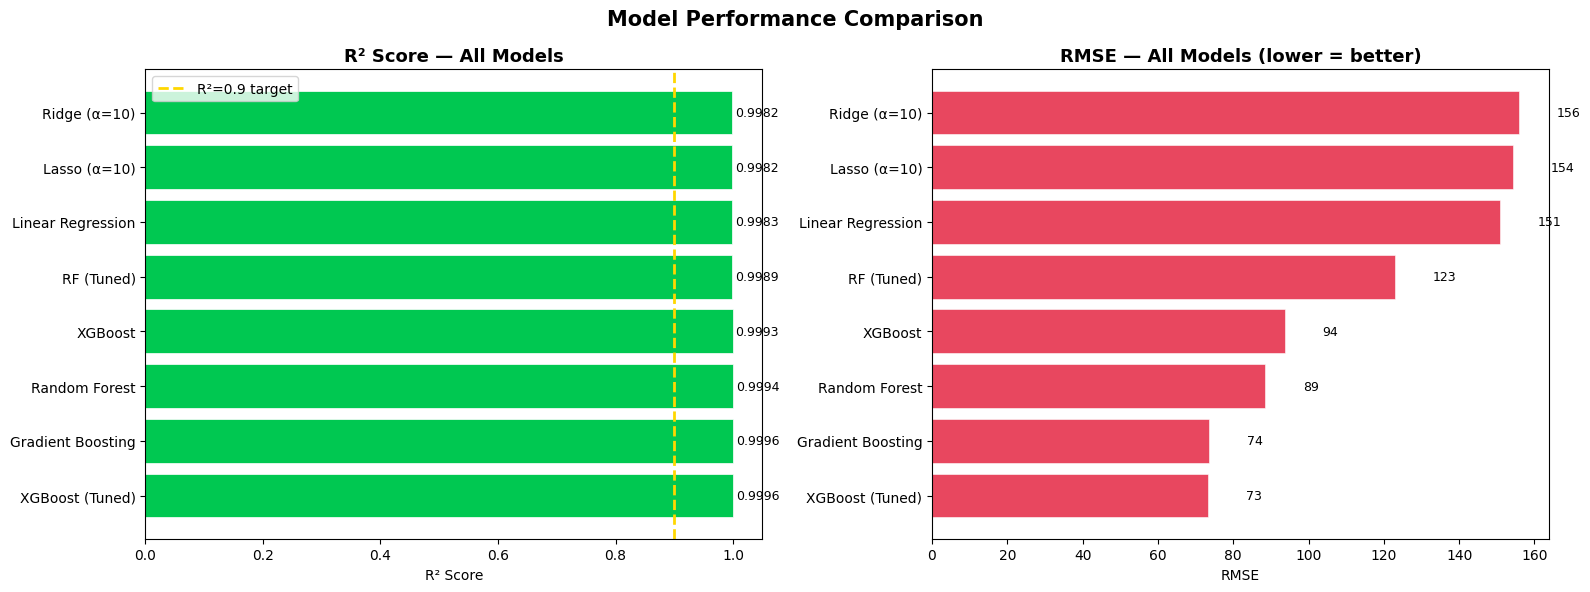

In [33]:
metrics_df = pd.DataFrame({
    'Model': [r['name'] for r in models_results],
    'R²':    [r['r2'] for r in models_results],
    'RMSE':  [r['rmse'] for r in models_results]
}).sort_values('R²', ascending=False).reset_index(drop=True)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#00C851' if v >= 0.9 else '#00A3E0' if v >= 0.7 else '#FF8C00'
          for v in metrics_df['R²']]
bars = axes[0].barh(metrics_df['Model'], metrics_df['R²'],
                    color=colors, edgecolor='white', linewidth=0.5)
axes[0].axvline(0.9, color='gold', ls='--', lw=2, label='R²=0.9 target')
axes[0].set_title('R² Score — All Models', fontsize=13, fontweight='bold')
axes[0].set_xlabel('R² Score')
axes[0].legend()
for bar, val in zip(bars, metrics_df['R²']):
    axes[0].text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

axes[1].barh(metrics_df['Model'], metrics_df['RMSE'],
             color='#E31937', alpha=0.8, edgecolor='white', linewidth=0.5)
axes[1].set_title('RMSE — All Models (lower = better)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('RMSE')
for bar, val in zip(axes[1].patches, metrics_df['RMSE']):
    axes[1].text(bar.get_width()+10, bar.get_y()+bar.get_height()/2,
                 f'{val:,.0f}', va='center', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

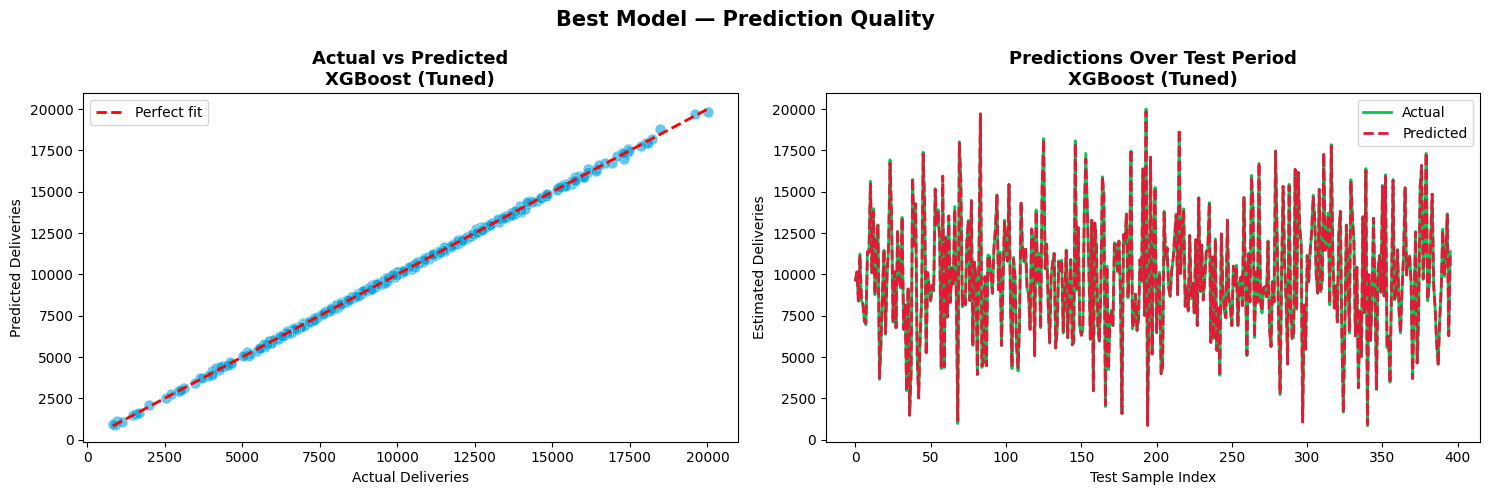

In [34]:
best_result = max(models_results, key=lambda x: x['r2'])
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
y_pred_best = best_result['pred']
axes[0].scatter(y_test, y_pred_best, alpha=0.6, color='#00A3E0',
                edgecolors='white', linewidths=0.4, s=60)
mn = min(y_test.min(), y_pred_best.min())
mx = max(y_test.max(), y_pred_best.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect fit')
axes[0].set_title(f'Actual vs Predicted\n{best_result["name"]}',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual Deliveries')
axes[0].set_ylabel('Predicted Deliveries')
axes[0].legend()

x_axis = range(len(y_test))
axes[1].plot(x_axis, y_test.values, label='Actual',    color='#00C851', lw=2)
axes[1].plot(x_axis, y_pred_best,   label='Predicted', color='#E31937', lw=2, ls='--')
axes[1].fill_between(x_axis, y_test.values, y_pred_best, alpha=0.15, color='gray')
axes[1].set_title(f'Predictions Over Test Period\n{best_result["name"]}',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Test Sample Index')
axes[1].set_ylabel('Estimated Deliveries')
axes[1].legend()

plt.suptitle('Best Model — Prediction Quality', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

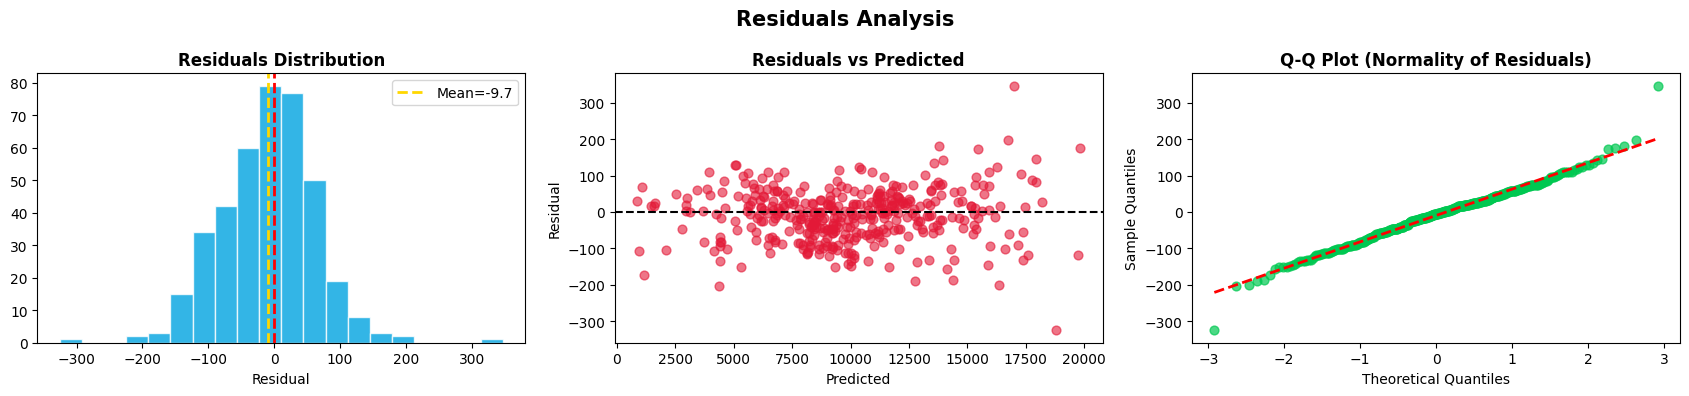

  Residual Mean  : -9.68  (closer to 0 = better)
  Residual Std   : 72.73


In [35]:
residuals = y_test.values - y_pred_best
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].hist(residuals, bins=20, color='#00A3E0', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', lw=2, ls='--')
axes[0].axvline(residuals.mean(), color='gold', lw=2, ls='--', label=f'Mean={residuals.mean():.1f}')
axes[0].set_title('Residuals Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Residual'); axes[0].legend()

axes[1].scatter(y_pred_best, residuals, alpha=0.6, color='#E31937', s=40)
axes[1].axhline(0, color='black', lw=1.5, ls='--')
axes[1].set_title('Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residual')

from scipy import stats
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
axes[2].scatter(osm, osr, color='#00C851', alpha=0.7, s=40)
axes[2].plot(osm, slope*np.array(osm)+intercept, 'r--', lw=2)
axes[2].set_title('Q-Q Plot (Normality of Residuals)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Theoretical Quantiles')
axes[2].set_ylabel('Sample Quantiles')
plt.suptitle('Residuals Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"  Residual Mean  : {residuals.mean():.2f}  (closer to 0 = better)")
print(f"  Residual Std   : {residuals.std():.2f}")

In [36]:
df_ts = df_cleaned.copy()
df_ts['Date'] = pd.to_datetime(df_ts['Year'].astype(str) + '-' +
                               df_ts['Month'].astype(str) + '-01')

monthly_data = df_ts.groupby('Date').agg({
    'Estimated_Deliveries': 'sum',
    'Production_Units':     'sum'
}).asfreq('MS')

print(f"Monthly series: {len(monthly_data)} periods  "
      f"({monthly_data.index[0].date()} → {monthly_data.index[-1].date()})")
monthly_data.head()


Monthly series: 132 periods  (2015-01-01 → 2025-12-01)


,Estimated_Deliveries,Production_Units
Date,,
2015-01-01,183180.000,195793.000
2015-02-01,165053.000,176119.000
2015-03-01,179494.625,193279.125
2015-04-01,225623.000,241706.000
2015-05-01,184264.000,198205.000


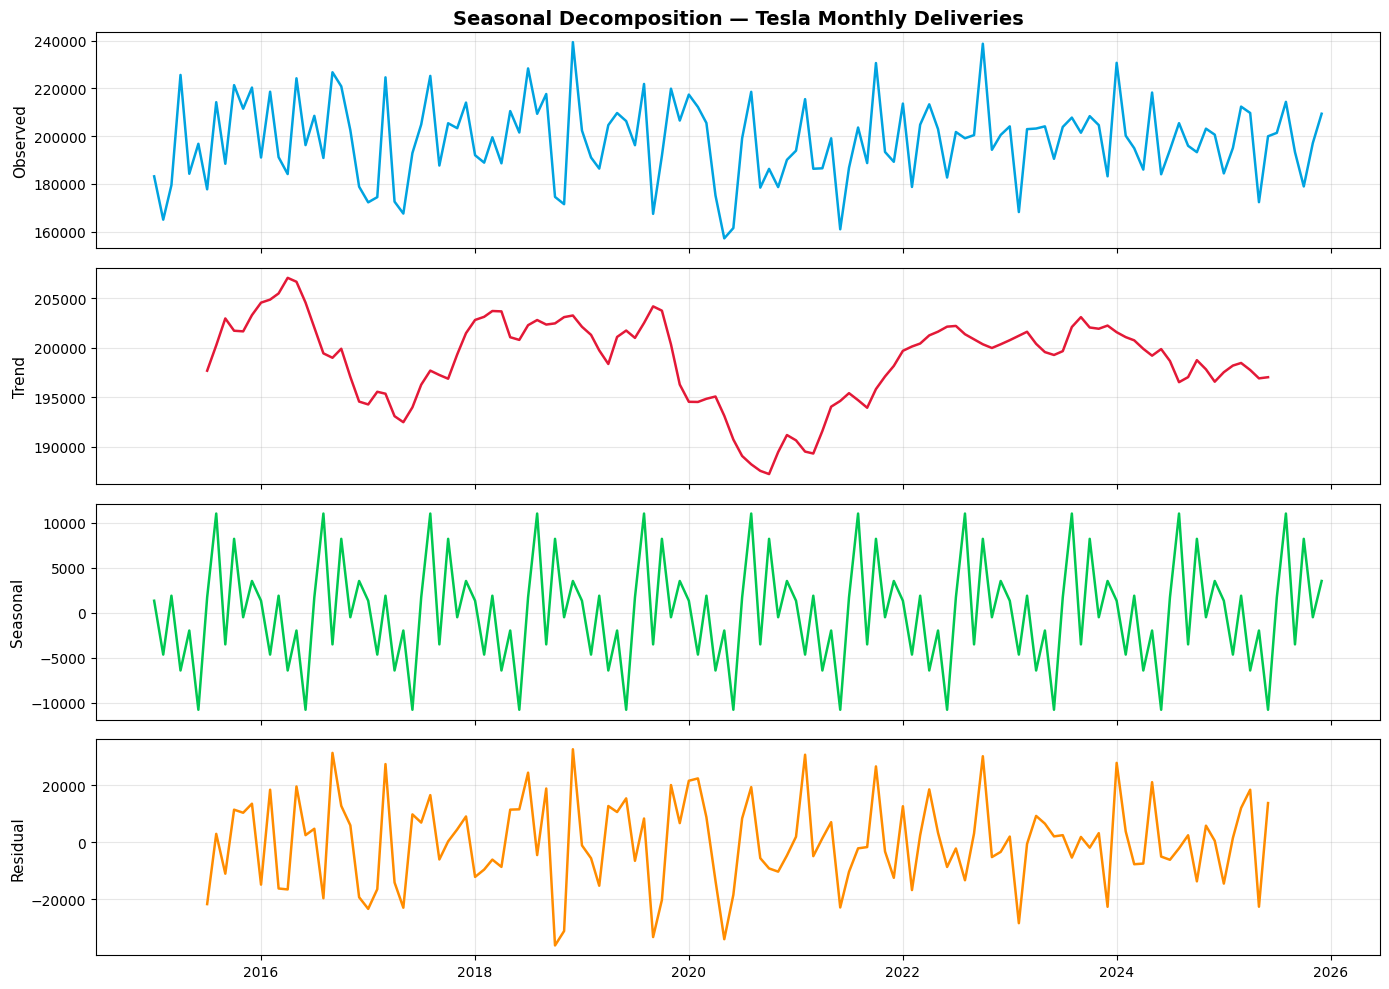

In [37]:
decomp = seasonal_decompose(monthly_data['Estimated_Deliveries'],
                             model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
components = [('Observed',  monthly_data['Estimated_Deliveries'], '#00A3E0'),
              ('Trend',     decomp.trend,    '#E31937'),
              ('Seasonal',  decomp.seasonal, '#00C851'),
              ('Residual',  decomp.resid,    '#FF8C00')]

for ax, (label, data, color) in zip(axes, components):
    ax.plot(data, color=color, lw=1.8)
    ax.set_ylabel(label, fontsize=11)
    ax.grid(True, alpha=0.3)

axes[0].set_title('Seasonal Decomposition — Tesla Monthly Deliveries',
                  fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


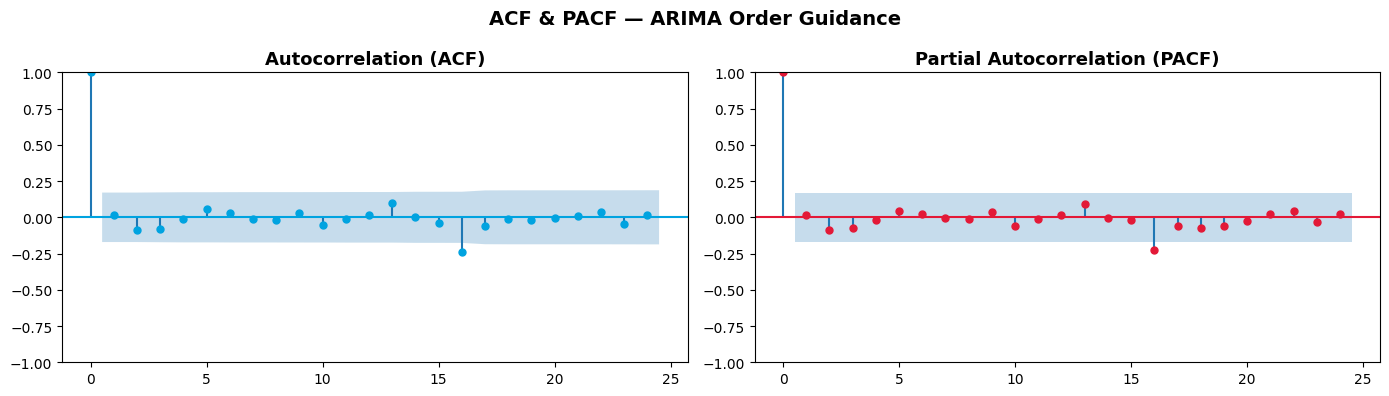

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(monthly_data['Estimated_Deliveries'].dropna(),
         lags=24, ax=axes[0], color='#00A3E0')
axes[0].set_title('Autocorrelation (ACF)', fontsize=13, fontweight='bold')
plot_pacf(monthly_data['Estimated_Deliveries'].dropna(),
          lags=24, ax=axes[1], color='#E31937')
axes[1].set_title('Partial Autocorrelation (PACF)', fontsize=13, fontweight='bold')
plt.suptitle('ACF & PACF — ARIMA Order Guidance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [39]:
split_idx    = int(len(monthly_data) * 0.85)
train_series = monthly_data.iloc[:split_idx]
test_series  = monthly_data.iloc[split_idx:]
y_train_ts, X_train_ts = train_series['Estimated_Deliveries'], train_series[['Production_Units']]
y_test_ts,  X_test_ts  = test_series['Estimated_Deliveries'],  test_series[['Production_Units']]

In [40]:
model = SARIMAX(endog=y_train_ts, exog=X_train_ts,
                order=(1, 1, 1),
                seasonal_order=(1, 1, 0, 12),
                enforce_stationarity=False,
                enforce_invertibility=False)
sarimax_fit = model.fit(disp=False)

In [41]:
print(f"SARIMAX AIC : {sarimax_fit.aic:.2f}")
print(f"SARIMAX BIC : {sarimax_fit.bic:.2f}")

SARIMAX AIC : 1588.74
SARIMAX BIC : 1601.01


In [42]:
predictions = sarimax_fit.predict(start=y_test_ts.index[0],
                                   end=y_test_ts.index[-1],
                                   exog=X_test_ts, dynamic=False)

ts_rmse = np.sqrt(mean_squared_error(y_test_ts, predictions))
ts_mae  = mean_absolute_error(y_test_ts, predictions)

print("=" * 45)
print("  SARIMAX EVALUATION REPORT")
print("=" * 45)
print(f"  RMSE : {ts_rmse:,.2f}")
print(f"  MAE  : {ts_mae:,.2f}")
print("=" * 45)

last_prod = monthly_data['Production_Units'].values[-1]
future_exog = pd.DataFrame({'Production_Units': [last_prod*1.03**i for i in range(1,13)]},
                            index=pd.date_range(monthly_data.index[-1]+pd.DateOffset(months=1),
                                                periods=12, freq='MS'))
forecast_obj  = sarimax_fit.get_forecast(steps=12, exog=future_exog)
forecast_mean = forecast_obj.predicted_mean
forecast_ci   = forecast_obj.conf_int()

print("\n12-Month Delivery Forecast:")
for dt, val in forecast_mean.items():
    print(f"  {dt.strftime('%b %Y')}  →  {val:,.0f}")


  SARIMAX EVALUATION REPORT
  RMSE : 2,292.79
  MAE  : 1,907.97

12-Month Delivery Forecast:
  May 2024  →  214,718
  Jun 2024  →  223,846
  Jul 2024  →  229,581
  Aug 2024  →  237,213
  Sep 2024  →  242,474
  Oct 2024  →  251,920
  Nov 2024  →  259,181
  Dec 2024  →  266,067
  Jan 2025  →  273,524
  Feb 2025  →  281,032
  Mar 2025  →  289,750
  Apr 2025  →  299,335


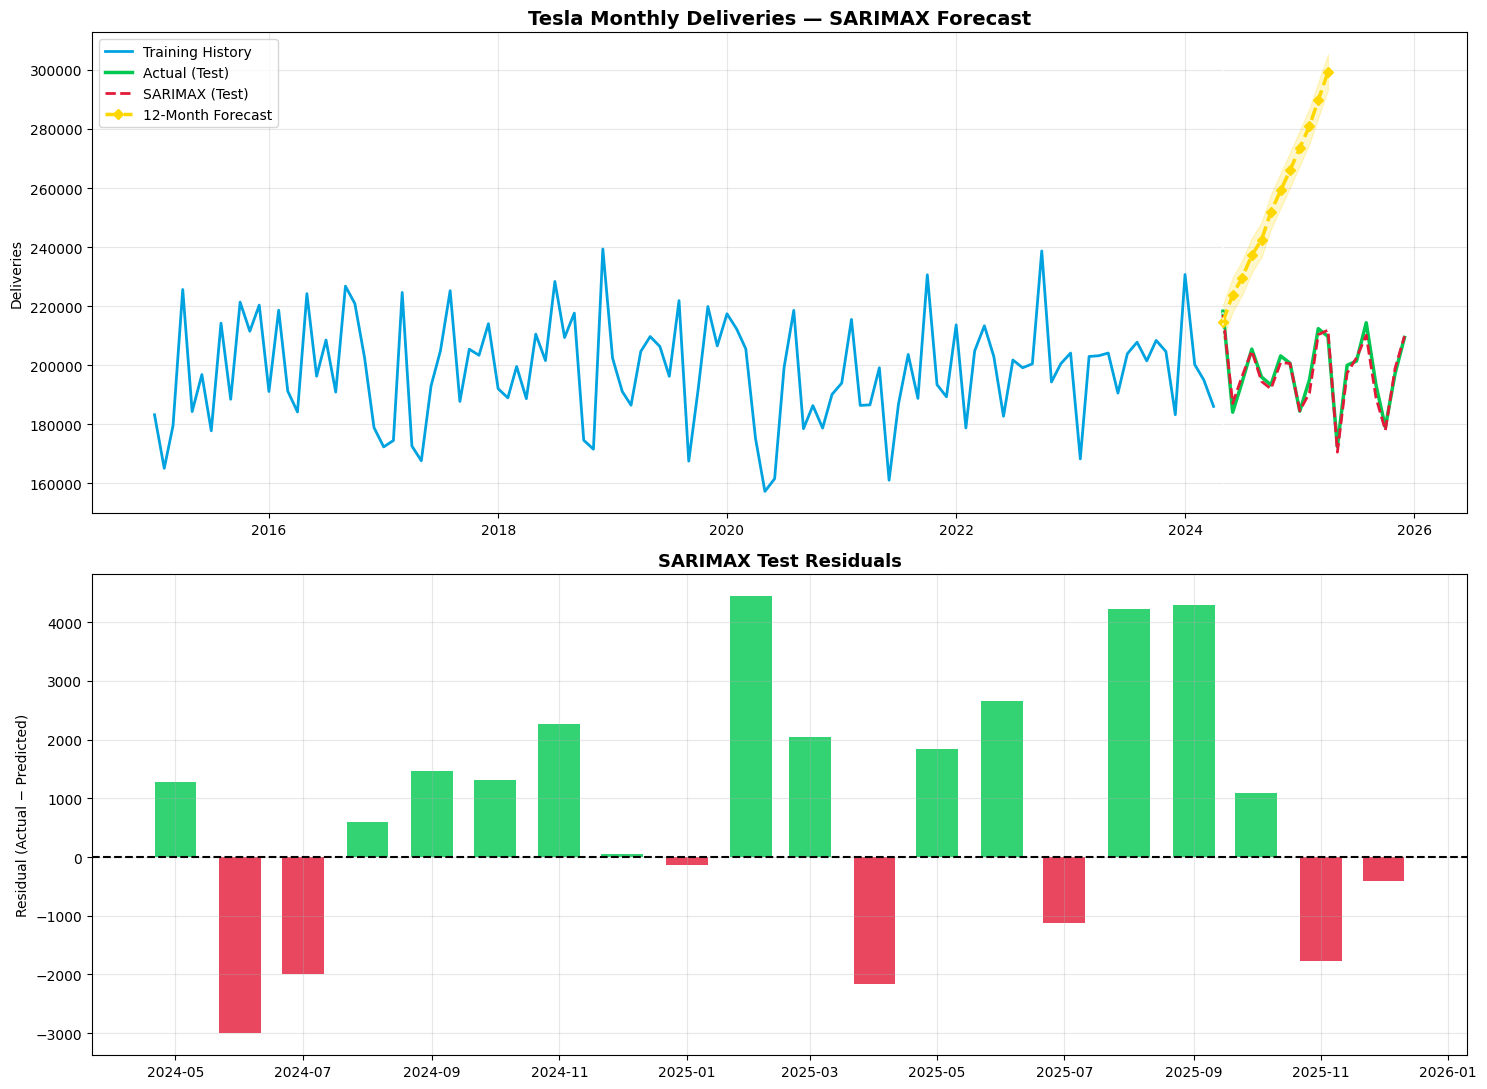

In [43]:
fig, axes = plt.subplots(2, 1, figsize=(15, 11))
ax = axes[0]
ax.plot(train_series.index, y_train_ts, color='#00A3E0', lw=2, label='Training History')
ax.plot(test_series.index,  y_test_ts,  color='#00C851', lw=2.5, label='Actual (Test)')
ax.plot(predictions.index,  predictions, color='#E31937', lw=2, ls='--', label='SARIMAX (Test)')
ax.plot(forecast_mean.index, forecast_mean, color='#FFD700', lw=2.5, ls='--',
        marker='D', ms=5, label='12-Month Forecast')
ax.fill_between(forecast_ci.index, forecast_ci.iloc[:,0], forecast_ci.iloc[:,1],
                alpha=0.2, color='#FFD700')
ax.axvline(test_series.index[0], color='white', lw=1.5, ls=':', alpha=0.7)
ax.set_title('Tesla Monthly Deliveries — SARIMAX Forecast', fontsize=14, fontweight='bold')
ax.set_ylabel('Deliveries'); ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

ts_residuals = y_test_ts.values - predictions.values
ax2 = axes[1]
ax2.bar(test_series.index, ts_residuals,
        color=['#00C851' if v > 0 else '#E31937' for v in ts_residuals],
        alpha=0.8, width=20)
ax2.axhline(0, color='black', lw=1.5, ls='--')
ax2.set_title('SARIMAX Test Residuals', fontsize=13, fontweight='bold')
ax2.set_ylabel('Residual (Actual − Predicted)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [44]:
print("=" * 65)
print("  END-TO-END ML PIPELINE — SUMMARY")
print("=" * 65)
print(f"  Dataset rows used       : {df_feat.shape[0]}")
print(f"  Total features          : {len(num_features) + len(cat_features)}")
print(f"  Models trained          : {len(models_results)}")
print(f"  Best model              : {best_result['name']}")
print(f"  Best R²                 : {best_result['r2']:.4f}")
print(f"  Best RMSE               : {best_result['rmse']:,.1f}")
print(f"  SARIMAX AIC             : {sarimax_fit.aic:.2f}")
print(f"  12-mo Forecast (peak)   : {forecast_mean.max():,.0f} deliveries/month")

  END-TO-END ML PIPELINE — SUMMARY
  Dataset rows used       : 2634
  Total features          : 21
  Models trained          : 8
  Best model              : XGBoost (Tuned)
  Best R²                 : 0.9996
  Best RMSE               : 73.4
  SARIMAX AIC             : 1588.74
  12-mo Forecast (peak)   : 299,335 deliveries/month
